Code to read in Caitlin's base FP catalogue, and convert it to a clustering catalogue by cross-matching with the BGS clustering catalogue, attaching weights and then returning a subset of the columns

In [12]:
import fitsio
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table, vstack
import matplotlib.pyplot as plt
from sklearn.neighbors import KDTree
from astropy.cosmology import FlatLambdaCDM
import matplotlib.colors as colors

LightSpeed = 299792.458
zmin = 0.01        # minimum redshift for selection
zmax = 0.1         # maximum redshift for selection
rfact = 20         # size of final random catalogue relative to data
ngrid = 128        # grid size for number density
nzbin = 36         # number of redshift bins for plotting
rsets = 18         # number of DESI random catalogues to use
survey_area = 12378.1064 * (np.pi/180.0)**2
cosmo = FlatLambdaCDM(H0=100,Om0=0.3151)
deccel = 3.0*0.3151/2.0 - 1.0
version = 4
stem = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/'

In [13]:
# Useful utilities
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def weighted_avg_and_std(values, weights, axis=None):
    average = np.average(values, weights=weights, axis=axis)
    average_err = np.std(values)*np.sqrt(np.sum((weights/np.sum(weights))**2))
    variance = np.average((values-average)**2, weights=weights, axis=axis)
    return (average, average_err, np.sqrt(variance))

# Heliocentric to CMB frame conversion routine from Anthony Carr.
def perform_corr(z_inp, RA, Dec, corrtype="full", dipole="Planck"):

    """
    A function to perform heliocentric corrections on redshifts.

    
    Inputs
    ======
    
    z_inp : float
        input heliocentric or CMB frame redshift
    
    RA : float
        equatorial right ascension
    
    Dec : float
        equatorial declination
    
    corrtype : string
        The type of correction to be performed. Either 'full' (default), 
        'approx',
        
        '-full' or '-approx', respectively corresponding to the proper 
        correction, low-z additive approximation, and the backwards corrections 
        to go from z_CMB to z_helio.
    
    dipole : string
        'Planck', 'COBE' or 'Astropy' dipoles. 'Astropy' imports astropy (slow) 
        and uses their co-ordinates and transforms and COBE dipole; different 
        beyond first decimal point.

    
    Outputs
    =======
    
    z_CMB : float
        (if corrtype is 'full' or 'approx')
    
    z_helio : float
        (only if corrtype is '-full' or '-approx')


    Notes
    =====
    
    Co-ords of North Galactic Pole (ICRS): 
        RA = 192.729 ± 0.035 deg, Dec = 27.084 ± 0.023 deg 
        (https://doi.org/10.1093/mnras/stw2772)
    
    Co-ords of Galactic Centre (ICRS): 
        RA = 17h45m40.0409s, Dec = −29d00m28.118s (see above reference)
        RA = 266.41683708 deg, Dec = -29.00781056 deg
    
    Ascending node of the galactic plane 
        = arccos(sin(Dec_GC)*cos(Dec_NGP)-cos(Dec_GC)*sin(Dec_NGP)*cos(RA_NGP-RA_GC))
        = 122.92828126730255 
        = l_0
    
    Transform CMB dipole from (l,b) to (RA,Dec):
        Dec = arcsin(sin(Dec_NGP)*sin(b)+cos(Dec_NGP)*cos(b)*cos(l_0-l))
            = -6.9895105228347 deg
        RA = RA_NGP + arctan((cos(b)*sin(l_0-l)) / (cos(Dec_NGP)*sin(b)-sin(Dec_NGP)*cos(b)*cos(l_0-l)))
            = 167.81671014708002 deg
    
    Astropy co-ordinates:
        RA_NGP_J2000 = 192.8594812065348, Dec_NGP_J2000 = 27.12825118085622, which are converted from B1950
        RA_NGP_B1950 = 192.25, Dec_NGP_B1950 = 27.4
        l_0_B1950 = 123
        l_0_J2000 = 122.9319185680026
    """

    v_Sun_Planck = 369.82  # +/- 0.11 km/s
    l_dipole_Planck = 264.021  # +/- 0.011 deg
    b_dipole_Planck = 48.253  # +/- 0.005 deg
    c = 299792.458  # km/s
    v_Sun_COBE = 371.0
    l_dipole_COBE = 264.14
    b_dipole_COBE = 48.26

    RA_Sun_Planck = 167.81671014708002  # deg
    Dec_Sun_Planck = -6.9895105228347
    RA_Sun_COBE = 167.88112630619747  # deg
    Dec_Sun_COBE = -7.024553155965497

    # RA_Sun_COBE = 168.01187366045565  # deg using Astropy values     # 168.0118667
    # Dec_Sun_COBE = -6.983037861854297  # # # -6.98303424

    if corrtype not in ["full", "approx", "-full", "-approx"]:
        print("Correction type unknown.")
        raise ValueError

    rad = np.pi / 180.0
    if dipole == "Planck":
        # Vincenty formula
        alpha = np.arctan2(
            np.hypot(
                np.cos(Dec_Sun_Planck * rad) * np.sin(np.fabs(RA - RA_Sun_Planck) * rad),
                np.cos(Dec * rad) * np.sin(Dec_Sun_Planck * rad)
                - np.sin(Dec * rad)
                * np.cos(Dec_Sun_Planck * rad)
                * np.cos(np.fabs(RA - RA_Sun_Planck) * rad),
            ),
            np.sin(Dec * rad) * np.sin(Dec_Sun_Planck * rad)
            + np.cos(Dec * rad)
            * np.cos(Dec_Sun_Planck * rad)
            * np.cos(np.fabs((RA - RA_Sun_Planck)) * rad),
        )
    elif dipole == "COBE":
        alpha = np.arctan2(
            np.hypot(
                np.cos(Dec_Sun_COBE * rad) * np.sin(np.fabs(RA - RA_Sun_COBE) * rad),
                np.cos(Dec * rad) * np.sin(Dec_Sun_COBE * rad)
                - np.sin(Dec * rad)
                * np.cos(Dec_Sun_COBE * rad)
                * np.cos(np.fabs(RA - RA_Sun_COBE) * rad),
            ),
            np.sin(Dec * rad) * np.sin(Dec_Sun_COBE * rad)
            + np.cos(Dec * rad)
            * np.cos(Dec_Sun_COBE * rad)
            * np.cos(np.fabs((RA - RA_Sun_COBE)) * rad),
        )
    elif dipole == "astropy":
        coord_helio_COBE = SkyCoord(l_dipole_COBE * u.degree, 
                                    b_dipole_COBE * u.degree, 
                                    frame="galactic").galactic
        coord = SkyCoord(RA * u.degree, Dec * u.degree, frame="icrs").galactic
        alpha = coord_helio_COBE.separation(coord).radian
    
    if dipole == "Planck":
        v_Sun_proj = v_Sun_Planck * np.cos(alpha)
    elif dipole in ["COBE", "astropy"]:
        v_Sun_proj = v_Sun_COBE * np.cos(alpha)

    # z_Sun = -v_Sun_proj / c
    # Full special rel. correction since it is a peculiar vel
    #z_Sun = np.sqrt((1.0 + (-v_Sun_proj) / c) / (1.0 - (-v_Sun_proj) / c)) - 1.0
    z_Sun = -v_Sun_proj/c

    min_z = 0.0
    if corrtype == "full":
        z_CMB = np.where(z_inp <= min_z, z_inp, (1 + z_inp) / (1 + z_Sun) - 1)
    elif (corrtype == "-full"):
        # backwards correction where z_CMB is actually z_helio and vice versa
        z_helio = np.where(z_inp <= min_z, z_inp, (1 + z_inp) * (1 + z_Sun) - 1)
    elif corrtype == "approx":
        z_CMB = np.where(z_inp <= min_z, z_inp, z_inp - z_Sun)
    elif corrtype == "-approx":
        z_helio = np.where(z_inp <= min_z, z_inp,  z_inp + z_Sun)

    if corrtype[0] == "-":
        return z_helio
    else:
        return z_CMB

def process_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify duplicate (ra, dec) pairs, summarise their properties, and assign
    a bgs_targetid column for BGS crossmatching. Returns the input dataframe 
    with bgs_targetid added.
    """
    from itertools import combinations

    def overlap_matrix(dups: pd.DataFrame, col: str) -> pd.DataFrame:
        pair_counts = {}
        for _, group in dups.groupby(['ra', 'dec'])[col]:
            vals = sorted(group.tolist())
            for a, b in combinations(vals, 2):
                key = (min(a, b), max(a, b))
                pair_counts[key] = pair_counts.get(key, 0) + 1
        cats = sorted(dups[col].unique())
        matrix = pd.DataFrame(0, index=cats, columns=cats)
        for (a, b), count in pair_counts.items():
            matrix.loc[a, b] = count
            if a != b:
                matrix.loc[b, a] = count
        return matrix

    # ------------------------------------------------------------------ #
    # 1. Identify duplicates
    # ------------------------------------------------------------------ #
    dup_mask = df.duplicated(subset=['ra', 'dec'], keep=False)
    dups = df[dup_mask].copy()
    dups['n_obs'] = dups.groupby(['ra', 'dec'])['ra'].transform('size')

    print("=== Duplicate Summary ===")
    print(f"Total rows:               {len(df)}")
    print(f"Unique (ra, dec) pairs:   {df.groupby(['ra', 'dec']).ngroups}")
    print(f"Singleton objects:        {(~dup_mask).sum()}")
    print(f"Rows involved in dups:    {len(dups)}")
    print(f"Unique dup sky positions: {dups.groupby(['ra', 'dec']).ngroups}")

    print("\n=== Multiplicity breakdown (n_obs: n_objects) ===")
    print(dups.drop_duplicates(subset=['ra', 'dec'])['n_obs'].value_counts().sort_index().to_string())

    print("\n=== Program overlap matrix ===")
    print(overlap_matrix(dups, 'program').to_string())

    print("\n=== Survey overlap matrix ===")
    print(overlap_matrix(dups, 'survey').to_string())

    print("\n=== Singleton breakdown by survey and program ===")
    singletons = df[~dup_mask]
    print(pd.crosstab(singletons['program'], singletons['survey'], margins=True, margins_name='Total').to_string())

    # ------------------------------------------------------------------ #
    # 2. Verify primaryVdisp flags
    # ------------------------------------------------------------------ #
    n_no_primary = n_multi_primary = n_wrong_primary = n_ok = 0
    for _, group in dups.groupby(['ra', 'dec']):
        primary = group[group['primaryVdisp'] == 1]
        if len(primary) == 0:
            n_no_primary += 1
        elif len(primary) > 1:
            n_multi_primary += 1
        elif primary.index[0] != group['es'].idxmin():
            n_wrong_primary += 1
        else:
            n_ok += 1

    print("\n=== primaryVdisp consistency check ===")
    print(f"Total duplicate groups:         {len(dups.groupby(['ra', 'dec']))}")
    print(f"OK (primary == smallest error): {n_ok}")
    print(f"No primary flagged:             {n_no_primary}")
    print(f"Multiple primaries flagged:     {n_multi_primary}")
    print(f"Primary != smallest error:      {n_wrong_primary}")

    # ------------------------------------------------------------------ #
    # 3. Check program of primary and bright availability
    # ------------------------------------------------------------------ #
    primary_programs = []
    has_bright_but_not_primary = 0
    for _, group in dups.groupby(['ra', 'dec']):
        primary = group[group['primaryVdisp'] == 1].iloc[0]
        primary_programs.append(primary['program'])
        if primary['program'] != 'bright' and (group['program'] == 'bright').any():
            has_bright_but_not_primary += 1

    print("\n=== Program of primaryVdisp==1 in duplicate groups ===")
    print(pd.Series(primary_programs).value_counts().to_string())
    print(f"\nGroups where primary is non-bright but bright obs exists: {has_bright_but_not_primary}")

    # ------------------------------------------------------------------ #
    # 4. Assign bgs_targetid
    # ------------------------------------------------------------------ #
    result = df.copy()
    
    # Map (ra, dec) -> bright/main targetid for duplicate groups
    # Sort so main comes first to ensure bright/main is prioritised over bright/sv3 etc.
    bright_dups = dups[dups['program'] == 'bright'].copy()
    bright_dups['survey_priority'] = (bright_dups['survey'] != 'main').astype(int)
    bright_map = (
        bright_dups.sort_values('survey_priority')
        .groupby(['ra', 'dec'])['targetid']
        .first()
        .to_dict()
    )
    result['bgs_targetid'] = pd.array(
        [bright_map.get((float(ra), float(dec)), pd.NA) for ra, dec in zip(df['ra'], df['dec'])],
        dtype='Int64'
    )
    
    # For bright/main singletons, bgs_targetid == targetid
    bright_singleton = (~dup_mask) & (df['program'] == 'bright') & (df['survey'] == 'main')
    result.loc[bright_singleton, 'bgs_targetid'] = df.loc[bright_singleton, 'targetid']
    
    print("\n=== BGS targetid assignment ===")
    print(f"Rows with bgs_targetid assigned:  {result['bgs_targetid'].notna().sum()}")
    print(f"Rows without bgs_targetid:        {result['bgs_targetid'].isna().sum()}")
    primary = result[result['FPcalibrator'] == 1]
    print(f"\nOf FPcalibrator==1 rows:")
    print(f"  With bgs_targetid:    {primary['bgs_targetid'].notna().sum()}")
    print(f"  Without bgs_targetid: {primary['bgs_targetid'].isna().sum()}")

    return result

# Read in the FP file and sort out the duplicates by adding the BGS 
data = pd.read_csv(f"/global/cfs/cdirs/desicollab/science/td/pv/fpgalaxies/Y3/v{version}/FP_pv_cat_v{version}_groupcorr.csv")
data = process_duplicates(data)
data = data.drop(data[data["FPcalibrator"]==0].index)
print(data.keys())

=== Duplicate Summary ===
Total rows:               200787
Unique (ra, dec) pairs:   168891
Singleton objects:        137579
Rows involved in dups:    63208
Unique dup sky positions: 31312

=== Multiplicity breakdown (n_obs: n_objects) ===
n_obs
2    30781
3      480
4       49
5        2

=== Program overlap matrix ===
        bright   dark
bright    3659  28862
dark     28862     14

=== Survey overlap matrix ===
          main  special  sv1  sv2   sv3
main     28337      806  597  633  1970
special    806       12   14    0   114
sv1        597       14    0    3    49
sv2        633        0    3    0     0
sv3       1970      114   49    0     0

=== Singleton breakdown by survey and program ===
survey     main  special  sv1  sv2  sv3   Total
program                                        
bright   128312      155  305  143  650  129565
dark       8013        0    1    0    0    8014
Total    136325      155  306  143  650  137579

=== primaryVdisp consistency check ===
Total dupl

In [14]:
# Read in the BGS clustering files (without absolute magnitude cuts) and crossmatch
BGS_BRIGHT_NGC_clustering = Table.read(stem+"/BGS_BRIGHT_NGC_clustering.dat.fits")
BGS_BRIGHT_NGC_clustering.remove_column("BITWEIGHTS")
BGS_BRIGHT_NGC_clustering = BGS_BRIGHT_NGC_clustering.to_pandas()
BGS_BRIGHT_NGC_clustering = BGS_BRIGHT_NGC_clustering[(BGS_BRIGHT_NGC_clustering["Z"] >= zmin) & (BGS_BRIGHT_NGC_clustering["Z"] <= zmax)]     # Redshift cut, just to make the cross-matching faster as the FP sample is already zcut
print("BGS_BRIGHT_NGC_clustering")
print(len(BGS_BRIGHT_NGC_clustering))
BGS_BRIGHT_SGC_clustering = Table.read(stem+"/BGS_BRIGHT_SGC_clustering.dat.fits")
BGS_BRIGHT_SGC_clustering.remove_column("BITWEIGHTS")
BGS_BRIGHT_SGC_clustering = BGS_BRIGHT_SGC_clustering.to_pandas()
BGS_BRIGHT_SGC_clustering = BGS_BRIGHT_SGC_clustering[(BGS_BRIGHT_SGC_clustering["Z"] >= zmin) & (BGS_BRIGHT_SGC_clustering["Z"] <= zmax)]     # Redshift cut, just to make the cross-matching faster as the FP sample is already zcut
print("BGS_BRIGHT_SGC_clustering")
print(len(BGS_BRIGHT_SGC_clustering))
BGS_BRIGHT_clustering = pd.concat([BGS_BRIGHT_NGC_clustering, BGS_BRIGHT_SGC_clustering])
print("BGS_BRIGHT_clustering")
print(len(BGS_BRIGHT_clustering))
print([key for key in BGS_BRIGHT_clustering.keys()])
print("================")

# Read in the fastspecfit catalogue to get the same luminosities used for our PV redshift catalogue
fsstem = '/global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/'
tables = []
for i in range(12):
    fsfile = f'fastspec-loa-main-bright-nside1-hp{i:02d}.fits'
    print(f"Reading: {fsstem}{fsfile}")
    
    # Read specific columns from HDU 2 directly into a Table
    t = Table.read(fsstem + fsfile, hdu=2)[['TARGETID', 'ABSMAG01_SDSS_R']]
    tables.append(t)

# Efficiently stack all collected tables into one
fstab = vstack(tables).to_pandas()
print(f'Read in {len(fstab)} fastspecfits objects')

# Cross match the three catalogues
BGS_BRIGHT_clustering = pd.merge(BGS_BRIGHT_clustering,fstab,on='TARGETID',how='inner')
print('Merged catalogue has',len(BGS_BRIGHT_clustering),'galaxies')

BGS_BRIGHT_NGC_clustering
813827
BGS_BRIGHT_SGC_clustering
321971
BGS_BRIGHT_clustering
1135798
['TARGETID', 'TILEID', 'Z', 'NTILE', 'RA', 'DEC', 'PHOTSYS', 'FRAC_TLOBS_TILES', 'WEIGHT_ZFAIL', 'PROB_OBS', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_SYS', 'flux_g_dered', 'flux_r_dered', 'flux_z_dered', 'flux_w1_dered', 'flux_w2_dered', 'NX', 'WEIGHT_FKP']
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp00.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp01.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp02.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp03.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp04.fits
Reading: /global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright

Read in 13185499 fastspecfits objects
Merged catalogue has 1135795 galaxies


In [15]:
data_BRIGHT = data.merge(BGS_BRIGHT_clustering, how='inner', left_on=['bgs_targetid'], right_on=['TARGETID'])

print(f"Total crossmatched:    {len(data_BRIGHT)}")
print(f"FPcalibrator==1:       {len(data_BRIGHT[data_BRIGHT['FPcalibrator']==1])}")
print(f"\nOf FPcalibrator==1 rows with bgs_targetid:")
fp_with_bgs = data[(data['FPcalibrator']==1) & (data['bgs_targetid'].notna())]
print(f"  Total:               {len(fp_with_bgs)}")
print(f"  Matched:             {len(data_BRIGHT[data_BRIGHT['FPcalibrator']==1])}")
print(f"  Unmatched:           {len(fp_with_bgs) - len(data_BRIGHT[data_BRIGHT['FPcalibrator']==1])}")

print(f"\n=== Unmatched FPcalibrator==1 by program/survey ===")
unmatched_fp = data[
    (data['FPcalibrator'] == 1) & 
    (data['bgs_targetid'].notna()) & 
    (~data['bgs_targetid'].isin(BGS_BRIGHT_clustering['TARGETID']))
]
print(pd.crosstab(unmatched_fp['program'], unmatched_fp['survey']))

Total crossmatched:    141861
FPcalibrator==1:       141861

Of FPcalibrator==1 rows with bgs_targetid:
  Total:               157180
  Matched:             141861
  Unmatched:           15319

=== Unmatched FPcalibrator==1 by program/survey ===
survey    main  special  sv1  sv2  sv3
program                               
bright   12721       57   64   47   67
dark      2361        2    0    0    0


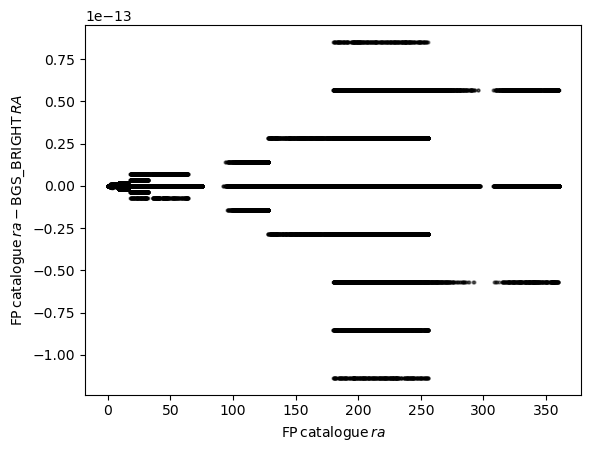

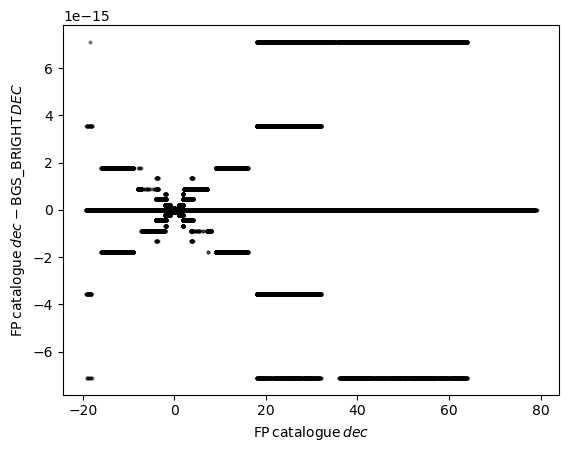

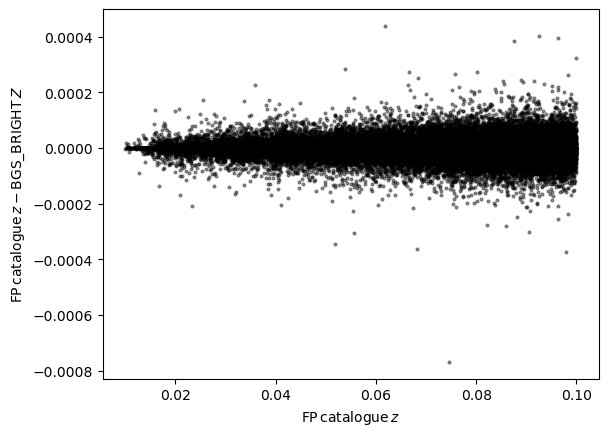

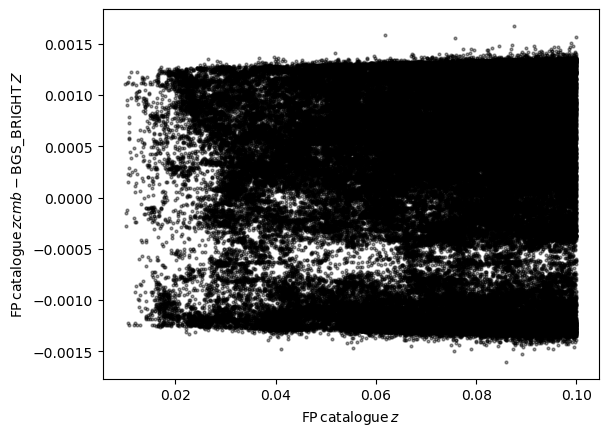

141861 130234


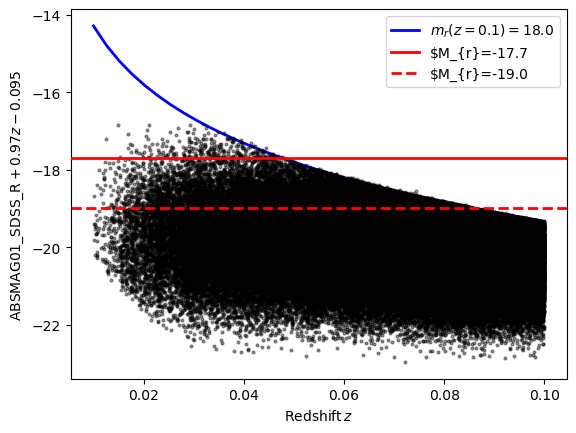

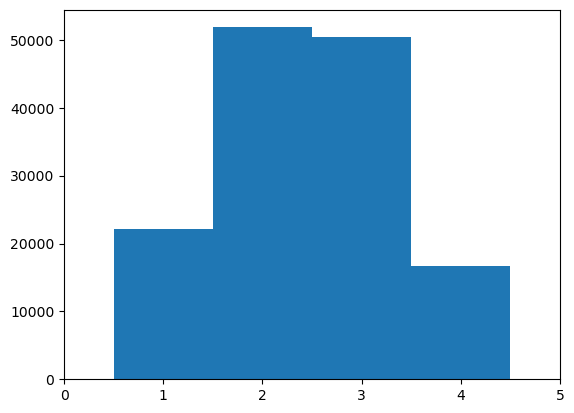

In [18]:
# There's some small differences between the various redshifts in the cross-match. Needs checking....
plt.errorbar(data_BRIGHT["ra"], data_BRIGHT["ra"] - data_BRIGHT["RA"], color='k', ls="None", marker='o', ms=2, alpha=0.4)
plt.xlabel(r'$\mathrm{FP\,catalogue}\,ra$')
plt.ylabel(r'$\mathrm{FP\,catalogue}\,ra - \mathrm{BGS\_BRIGHT}\,RA$')
plt.show();

plt.errorbar(data_BRIGHT["dec"], data_BRIGHT["dec"] - data_BRIGHT["DEC"], color='k', ls="None", marker='o', ms=2, alpha=0.4)
plt.xlabel(r'$\mathrm{FP\,catalogue}\,dec$')
plt.ylabel(r'$\mathrm{FP\,catalogue}\,dec - \mathrm{BGS\_BRIGHT}\,DEC$')
plt.show();

plt.errorbar(data_BRIGHT["z"], data_BRIGHT["z"] - data_BRIGHT["Z"], color='k', ls="None", marker='o', ms=2, alpha=0.4)
plt.xlabel(r'$\mathrm{FP\,catalogue}\,z$')
plt.ylabel(r'$\mathrm{FP\,catalogue}\,z - \mathrm{BGS\_BRIGHT}\,Z$')
plt.show();

plt.errorbar(data_BRIGHT["z"], data_BRIGHT["zcmb"] - data_BRIGHT["Z"], color='k', ls="None", marker='o', ms=2, alpha=0.4)
plt.xlabel(r'$\mathrm{FP\,catalogue}\,z$')
plt.ylabel(r'$\mathrm{FP\,catalogue}\,zcmb - \mathrm{BGS\_BRIGHT}\,Z$')
plt.show();

# Plot the magnitude against redshift for our FP sample
cosmo = FlatLambdaCDM(H0=100,Om0=0.3151)
distmax = cosmo.comoving_distance(zmax).value

redbins = np.linspace(zmin, zmax, nzbin)
magline = 18.0 - 5.0*np.log10(cosmo.comoving_distance(redbins).value) - 25.0 - 0.97*redbins + 0.095
cluslumdat = data_BRIGHT["ABSMAG01_SDSS_R"] + 0.97*data_BRIGHT["Z"] - 0.095
print(len(cluslumdat), len(np.where(cluslumdat < -19.0)[0]))
plt.errorbar(data_BRIGHT["Z"], cluslumdat, color='k', ls="None", marker='o', ms=2, alpha=0.4)
plt.plot(redbins, magline, color='b', ls='-', lw=2.0, label="$m_{r}(z=0.1)=18.0$")
plt.axhline(y=-17.7, color='r', ls='-', lw=2.0, label="$M_{r}=-17.7", zorder=5)
plt.axhline(y=-19.0, color='r', ls='--', lw=2.0, label="$M_{r}=-19.0", zorder=5)
plt.xlabel(r'$\mathrm{Redshift}\,z$')
plt.ylabel(r'$\mathrm{ABSMAG01\_SDSS\_R}+0.97z-0.095$')
plt.legend()
plt.show();

plt.hist(data_BRIGHT["NTILE"], bins=[0.5,1.5,2.5,3.5,4.5])
plt.xticks([0,1,2,3,4,5])
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1096655/1845171067.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.plot((zlims[:-1]+zlims[1:])/2.0, nzdat/volume, color='k', ls='-', lw=1.5, label="$\mathrm{Redshift\,catalogue,\,No\,M_{r}\,cut}$")
/tmp/ipykernel_1096655/1845171067.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.plot((zlims[:-1]+zlims[1:])/2.0, nzclusdat/volume, color='r', ls='-', lw=1.5, label="$\mathrm{Redshift\,catalogue,\,M_{r}<=-17.7}$")
/tmp/ipykernel_1096655/1845171067.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.plot((zlims[:-1]+zlims[1:])/2.0, nzfp/volume, color='b', ls='-', lw=1.5, label="$\mathrm{PV\,catalogue}$")


Index(['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'], dtype='str')
Index(['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'], dtype='str')
0.007522312472778819
0.007522312472778819


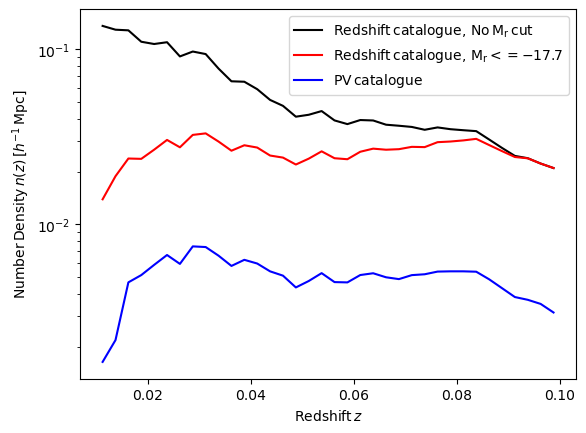

In [6]:
# Read in the forPV clustering data (has a 17.7 magnitude limit)
BGS_BRIGHT_clustering_forPV_data = Table.read("/global/cfs/cdirs/desi/science/td/pv/bgsclustering/Y3/BGS_BRIGHT_clustering_forPV_data.fits").to_pandas()
print(BGS_BRIGHT_clustering_forPV_data.keys())

# Read in the forPV clustering randoms (has a 17.7 magnitude limit)
BGS_BRIGHT_clustering_forPV_ran = Table.read("/global/cfs/cdirs/desi/science/td/pv/bgsclustering/Y3/BGS_BRIGHT_clustering_forPV_random.fits").to_pandas()
print(BGS_BRIGHT_clustering_forPV_ran.keys())

print(np.amin(BGS_BRIGHT_clustering_forPV_data["NDENS"]))
print(np.amin(BGS_BRIGHT_clustering_forPV_ran["NDENS"]))

# Plot the number densities of the redshift sample
nwdat, nwfp = np.sum(BGS_BRIGHT_clustering_forPV_data["WEIGHT"]), np.sum(data_BRIGHT["WEIGHT"])
nzdat,zlims = np.histogram(BGS_BRIGHT_clustering["Z"],bins=nzbin,range=[zmin,zmax], weights=BGS_BRIGHT_clustering["WEIGHT"])
nzclusdat,zlims = np.histogram(BGS_BRIGHT_clustering_forPV_data["Z"],bins=nzbin,range=[zmin,zmax], weights=BGS_BRIGHT_clustering_forPV_data["WEIGHT"])
nzfp,zlims = np.histogram(data_BRIGHT["Z"],bins=nzbin,range=[zmin,zmax], weights=data_BRIGHT["WEIGHT"])
volume = survey_area/3.0 * (cosmo.comoving_distance(zlims[1:]).value**3 - cosmo.comoving_distance(zlims[:-1]).value**3)

plt.plot((zlims[:-1]+zlims[1:])/2.0, nzdat/volume, color='k', ls='-', lw=1.5, label="$\mathrm{Redshift\,catalogue,\,No\,M_{r}\,cut}$")
plt.plot((zlims[:-1]+zlims[1:])/2.0, nzclusdat/volume, color='r', ls='-', lw=1.5, label="$\mathrm{Redshift\,catalogue,\,M_{r}<=-17.7}$")
plt.plot((zlims[:-1]+zlims[1:])/2.0, nzfp/volume, color='b', ls='-', lw=1.5, label="$\mathrm{PV\,catalogue}$")
plt.yscale('log')
plt.xlabel(r'$\mathrm{Redshift}\,z$')
plt.ylabel(r'$\mathrm{Number\,Density}\,n(z)\,[h^{-1}\,\mathrm{Mpc}]$')
plt.legend();
plt.show();

In [7]:
# Now that the catalogue looks good, let's copy Chris's code for making the redshift clustering catalogue to also make a FP clustering catalogue with some randoms

# Read in clustering random catalogue
print('\nReading in clustering random catalogues...')
clusrasran,clusdecran,clusredran,clusweiran,clusnxran,clusntileran = np.array([]),np.array([]),np.array([]),np.array([]),np.array([]),np.array([])
for iset in range(rsets):
  bgsclusranfile = 'BGS_BRIGHT_NGC_' + str(iset) + '_clustering.ran.fits'
  print(stem+bgsclusranfile)
  hdulist = fits.open(stem+bgsclusranfile)
  table = hdulist[1].data
  clusrasran1 = table.field('RA')
  clusdecran1 = table.field('DEC')
  clusredran1 = table.field('Z')
  clusweiran1 = table.field('WEIGHT')
  clusnxran1 = table.field('NX')
  clusntileran1 = table.field('NTILE')
  hdulist.close()
  bgsclusranfile = 'BGS_BRIGHT_SGC_' + str(iset) + '_clustering.ran.fits'
  print(stem+bgsclusranfile)
  hdulist = fits.open(stem+bgsclusranfile)
  table = hdulist[1].data
  clusrasran2 = table.field('RA')
  clusdecran2 = table.field('DEC')
  clusredran2 = table.field('Z')
  clusweiran2 = table.field('WEIGHT')
  clusnxran2 = table.field('NX')
  clusntileran2 = table.field('NTILE')
  hdulist.close()
# Cut random catalogues to redshift range
  cut = (clusredran1 >= zmin) & (clusredran1 <= zmax)
  clusrasran1,clusdecran1,clusredran1,clusweiran1,clusnxran1,clusntileran1 = clusrasran1[cut],clusdecran1[cut],clusredran1[cut],clusweiran1[cut],clusnxran1[cut],clusntileran1[cut]
  cut = (clusredran2 >= zmin) & (clusredran2 <= zmax)
  clusrasran2,clusdecran2,clusredran2,clusweiran2,clusnxran2,clusntileran2 = clusrasran2[cut],clusdecran2[cut],clusredran2[cut],clusweiran2[cut],clusnxran2[cut],clusntileran2[cut]
# Concatenate into master random dataset
  clusrasran = np.concatenate((clusrasran,clusrasran1,clusrasran2))
  clusdecran = np.concatenate((clusdecran,clusdecran1,clusdecran2))
  clusredran = np.concatenate((clusredran,clusredran1,clusredran2))
  clusweiran = np.concatenate((clusweiran,clusweiran1,clusweiran2))
  clusnxran = np.concatenate((clusnxran,clusnxran1,clusnxran2))
  clusntileran = np.concatenate((clusntileran,clusntileran1,clusntileran2))
print(len(clusrasran),'randoms with',zmin,'< z <',zmax)

# Randomize the order of the random sources
print('\nRandomizing order of randoms...')
cut = np.arange(len(clusrasran))
np.random.shuffle(cut)
clusrasran,clusdecran,clusredran,clusweiran,clusnxran,clusntileran = clusrasran[cut],clusdecran[cut],clusredran[cut],clusweiran[cut],clusnxran[cut],clusntileran[cut]

# Sub-sampling fraction of density-field catalogue versus full randoms
print('\nSub-sampling random catalogue...')
subfracz = nzclusdat.astype(float)/nzdat.astype(float)
# Normalise to 1.0 to maximize size of random catalogue
subfracz /= np.amax(subfracz)
print('Sub-sampling fraction =',subfracz)

# Sub-sampling fraction of FP catalogue versus full randoms
print('\nSub-sampling random catalogue...')
subfraczfp = nzfp.astype(float)/nzdat.astype(float)
# Normalise to 1.0 to maximize size of random catalogue
subfraczfp /= np.amax(subfraczfp)
print('Sub-sampling fraction =',subfraczfp)


Reading in clustering random catalogues...
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_0_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_SGC_0_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_1_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_SGC_1_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_2_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_SGC_2_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_3_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_SGC_3_clustering.ran.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_NGC_4_clus

In [8]:
"""# Construct redshift-dependent number density from random catalogues for density
winweigrid = np.histogram(BGS_BRIGHT_clustering_forPV_ran["Z"].to_numpy(),bins=nzbin,range=[zmin,zmax], weights=BGS_BRIGHT_clustering_forPV_ran["WEIGHT"].to_numpy())[0]
ndensweigrid = (nwdat/volume)*(winweigrid/np.sum(winweigrid))

# Construct redshift-dependent number density from random catalogues from random catalogues for PV
winweigrid = np.histogram(clusredran,bins=nzbin,range=[zmin,zmax], weights=clusweiran)[0]
npvweigrid = (nwfp/volume)*(winweigrid/np.sum(winweigrid))

# Sub-sample random catalogue
cut = np.random.choice(len(clusrasran),rfact*len(data_BRIGHT),replace=False)
clusrasran,clusdecran,clusredran,clusweiran,clusnxran,clusntileran = clusrasran[cut],clusdecran[cut],clusredran[cut],clusweiran[cut],clusnxran[cut],clusntileran[cut]
print('\nRandom catalogue cut to',len(clusrasran),'sources')

# Sample both the density field and PV field number density at PV galaxy and random positions
ix = np.digitize(data_BRIGHT["Z"], np.linspace(zmin,zmax,nzbin+1)) - 1
clusndensdat = ndensweigrid[ix] * [Cassign[i-1] for i in data_BRIGHT["NTILE"]]
clusnpvdat = npvweigrid[ix] * [Cassign[i-1] for i in data_BRIGHT["NTILE"]]
ix = np.digitize(clusredran, np.linspace(zmin,zmax,nzbin+1)) - 1
clusndensran = ndensweigrid[ix] * [Cassign[i-1] for i in clusntileran.astype(int)]
clusnpvran = npvweigrid[ix] * [Cassign[i-1] for i in clusntileran.astype(int)]"""

# Box enclosing data
distmax = cosmo.comoving_distance(zmax).value
nx,ny,nz = ngrid,ngrid,ngrid
lx,ly,lz = 2.*distmax,2.*distmax,2.*distmax
dx,dy,dz = lx/nx,ly/ny,lz/nz
x0,y0,z0 = distmax,distmax,distmax
dvol = dx*dy*dz

# Apply sub-sampling to random catalogue
# This assumes luminosity distribution of data is even across the sky
izs = np.digitize(clusredran,np.linspace(zmin,zmax,nzbin+1)) - 1
clusnxran *= subfracz[izs]
cut = subfracz[izs] > np.random.uniform(size=len(clusredran))
clusrasrandens,clusdecrandens,clusredrandens,clusweirandens,clusnxrandens = clusrasran[cut],clusdecran[cut],clusredran[cut],clusweiran[cut],clusnxran[cut]
print(len(clusrasran),'density randoms after sub-sampling')

# Construct 3D number density from random catalogues for density
dist = cosmo.comoving_distance(clusredrandens).value
clusxran = dist*np.cos(np.radians(clusdecrandens))*np.cos(np.radians(clusrasrandens))
clusyran = dist*np.cos(np.radians(clusdecrandens))*np.sin(np.radians(clusrasrandens))
cluszran = dist*np.sin(np.radians(clusdecrandens))
winweigrid,edges = np.histogramdd(np.vstack([clusxran+x0,clusyran+y0,cluszran+z0]).transpose(),bins=(nx,ny,nz),range=((0.,lx),(0.,ly),(0.,lz)),density=False,weights=clusweirandens)
ndensweigrid = (nwdat/dvol)*(winweigrid/np.sum(winweigrid))

# Apply sub-sampling to random catalogue
# This assumes luminosity distribution of data is even across the sky
izs = np.digitize(clusredran,np.linspace(zmin,zmax,nzbin+1)) - 1
clusnxran *= subfraczfp[izs]
cut = subfraczfp[izs] > np.random.uniform(size=len(clusredran))
clusrasran,clusdecran,clusredran,clusweiran,clusnxran = clusrasran[cut],clusdecran[cut],clusredran[cut],clusweiran[cut],clusnxran[cut]
print(len(clusrasran),'PV randoms after sub-sampling')

# Construct 3D number density from random catalogues for PV
dist = cosmo.comoving_distance(clusredran).value
clusxran = dist*np.cos(np.radians(clusdecran))*np.cos(np.radians(clusrasran))
clusyran = dist*np.cos(np.radians(clusdecran))*np.sin(np.radians(clusrasran))
cluszran = dist*np.sin(np.radians(clusdecran))
winweigrid,edges = np.histogramdd(np.vstack([clusxran+x0,clusyran+y0,cluszran+z0]).transpose(),bins=(nx,ny,nz),range=((0.,lx),(0.,ly),(0.,lz)),density=False,weights=clusweiran)
npvweigrid = (nwfp/dvol)*(winweigrid/np.sum(winweigrid))

# Sample both the density field and PV field number density at PV galaxy and random positions
xlims = np.linspace(0.,lx,nx+1) - x0
ylims = np.linspace(0.,ly,ny+1) - y0
zlims = np.linspace(0.,lz,nz+1) - z0
dist = cosmo.comoving_distance(data_BRIGHT["Z"]).value
clusxdat = dist*np.cos(np.radians(data_BRIGHT["DEC"]))*np.cos(np.radians(data_BRIGHT["RA"]))
clusydat = dist*np.cos(np.radians(data_BRIGHT["DEC"]))*np.sin(np.radians(data_BRIGHT["RA"]))
cluszdat = dist*np.sin(np.radians(data_BRIGHT["DEC"]))
ix = np.digitize(clusxdat,xlims) - 1
iy = np.digitize(clusydat,ylims) - 1
iz = np.digitize(cluszdat,zlims) - 1
print(np.amin(ix), np.amax(ix), np.amin(iy), np.amax(iy), np.amin(iy), np.amax(iy)) 
clusndensdat = ndensweigrid[ix,iy,iz]
clusnpvdat = npvweigrid[ix,iy,iz]
ix = np.digitize(clusxran,xlims) - 1
iy = np.digitize(clusyran,ylims) - 1
iz = np.digitize(cluszran,zlims) - 1
print(np.amin(ix), np.amax(ix), np.amin(iy), np.amax(iy), np.amin(iy), np.amax(iy)) 
clusndensran = ndensweigrid[ix,iy,iz]
clusnpvran = npvweigrid[ix,iy,iz]

print(np.amin(clusndensdat), np.amin(clusndensran))
print(np.amin(clusnpvdat), np.amin(clusnpvran))

print('\nNumber density from grid:')
print('Data dens =',np.mean(clusndensdat),'+/-',np.std(clusndensdat))
print('Random dens =',np.mean(clusndensran),'+/-',np.std(clusndensran))
print('Data pv =',np.mean(clusnpvdat),'+/-',np.std(clusnpvdat))
print('Random pv =',np.mean(clusnpvran),'+/-',np.std(clusnpvran))

80333294 density randoms after sub-sampling
65962077 PV randoms after sub-sampling
0 127 2 124 2 124
0 127 1 125 1 125
0.0 0.0
0.0 1.1982391091363753e-05

Number density from grid:
Data dens = 0.02422811471125549 +/- 0.006081326244973125
Random dens = 0.023722846220868544 +/- 0.006336090008002332
Data pv = 0.004460226709881703 +/- 0.001247562395056148
Random pv = 0.004368191006189932 +/- 0.0012915966855762218


In [9]:
# For the PV clustering the FKP-style weights also have a <v^2> term, so we need a value for this for each random point. Let's generate one by assigning an error based on the nearest real galaxy
# This is now batched to avoid memory issues with the large query of the KDTree!!
n_ran = len(clusxran)
batch_size = 5000000 
tree_data = KDTree(np.c_[clusxdat, clusydat, cluszdat])

# Pre-allocate result arrays
clusranlogdisterroriginal = np.empty(n_ran)
clusranlogdisterr = np.empty(n_ran)
clusranlogdisterrnmc = np.empty(n_ran)

# Use .values for the lookup to avoid Pandas overhead inside the loop
err_orig_raw = data_BRIGHT["logdist_err"].values
err_gauss_raw = data_BRIGHT["logdist_gauss_err_BGS"].values
err_nmc_raw = data_BRIGHT["logdist_err_nmc"].values

# Batch Loop
for start in range(0, n_ran, batch_size):
    end = min(start + batch_size, n_ran)
    
    # Query current batch
    batch_coords = np.c_[clusxran[start:end], clusyran[start:end], cluszran[start:end]]
    nn = tree_data.query(batch_coords, return_distance=False, dualtree=True)
    indices = nn[:, 0]

    # Assign results using the pre-calculated factor and indexed values
    clusranlogdisterroriginal[start:end] = err_orig_raw[indices]
    clusranlogdisterr[start:end] = err_gauss_raw[indices]
    clusranlogdisterrnmc[start:end] = err_nmc_raw[indices]
    
    print(f"Processed through {end} / {n_ran}")

print("Batching complete.")

clusranmuerroriginal = 5.0 * clusranlogdisterroriginal
clusranmuerr = 5.0 * clusranlogdisterr
clusranmuerrnmc = 5.0 * clusranlogdisterrnmc

clusredrancmb = perform_corr(clusredran, clusrasran, clusdecran)
H_vals = cosmo.H(clusredrancmb).value
D_vals = cosmo.comoving_distance(clusredrancmb).value
global_factor = (LightSpeed * np.log(10.0)) / ((LightSpeed * (1.0 + clusredrancmb) / (H_vals * D_vals)) - 1.0)

clusranpverroriginal = global_factor * clusranlogdisterroriginal
clusranpverr = global_factor * clusranlogdisterr
clusranpverrnmc = global_factor * clusranlogdisterrnmc

Processed through 5000000 / 65962077
Processed through 10000000 / 65962077
Processed through 15000000 / 65962077
Processed through 20000000 / 65962077
Processed through 25000000 / 65962077
Processed through 30000000 / 65962077
Processed through 35000000 / 65962077
Processed through 40000000 / 65962077
Processed through 45000000 / 65962077
Processed through 50000000 / 65962077
Processed through 55000000 / 65962077
Processed through 60000000 / 65962077
Processed through 65000000 / 65962077
Processed through 65962077 / 65962077
Batching complete.


In [11]:
# Output the clustering files
print(np.amin(data_BRIGHT["Z"]))

# Output data catalogue
col1 = fits.Column(name='TARGETID',format='K',array=data_BRIGHT["TARGETID"])
col2 = fits.Column(name='RA',format='D',array=data_BRIGHT["RA"])
col3 = fits.Column(name='DEC',format='D',array=data_BRIGHT["DEC"])
col4 = fits.Column(name='Z',format='D',array=data_BRIGHT["Z"])
col5 = fits.Column(name='ZCMB',format='D',array=perform_corr(data_BRIGHT["Z"], data_BRIGHT["RA"], data_BRIGHT["DEC"]))
col6 = fits.Column(name='WEIGHT',format='D',array=data_BRIGHT["WEIGHT"])
col7 = fits.Column(name='NPV',format='D',array=clusnpvdat)
col8 = fits.Column(name='NDENS',format='D',array=clusndensdat)
col9 = fits.Column(name='LOGDIST',format='D',array=data_BRIGHT["logdist_groupcorr_BGS"])
col10 = fits.Column(name='LOGDIST_ERR',format='D',array=data_BRIGHT["logdist_gauss_err_BGS"])
col11 = fits.Column(name='P_SPIRAL',format='D',array=data_BRIGHT["p_spiral"])
col12 = fits.Column(name='NGROUP',format='D',array=data_BRIGHT["Ngroup_BGS"])
col13 = fits.Column(name='ABSMAG01_SDSS_R',format='D',array=data_BRIGHT["ABSMAG01_SDSS_R"])
hdulist = fits.BinTableHDU.from_columns([col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11,col12,col13])
outfile = f'./v{version}/FP_clustering_data_v{version}.fits'
print('\nWriting out data catalogue...')
print(outfile)
hdulist.writeto(outfile, overwrite=True)

np.savetxt(f'./v{version}/FP_clustering_data_v{version}.csv', 
           np.c_[data_BRIGHT["TARGETID"].to_numpy(), data_BRIGHT["RA"].to_numpy(), data_BRIGHT["DEC"].to_numpy(), data_BRIGHT["Z"].to_numpy(), perform_corr(data_BRIGHT["Z"], data_BRIGHT["RA"], data_BRIGHT["DEC"]), data_BRIGHT["WEIGHT"].to_numpy(), clusnpvdat, clusndensdat, data_BRIGHT["logdist_groupcorr_BGS"].to_numpy(), data_BRIGHT["logdist_gauss_err_BGS"].to_numpy(), data_BRIGHT["p_spiral"].to_numpy(), data_BRIGHT["Ngroup_BGS"].to_numpy(), data_BRIGHT["ABSMAG01_SDSS_R"].to_numpy()],
           header="TARGETID,RA,DEC,Z,ZCMB,WEIGHT,NPV,NDENS,LOGDIST,LOGDIST_ERR,P_SPIRAL,NGROUP,ABSMAG01_SDSS_R")

0.010029301794123592

Writing out data catalogue...
./v4/FP_clustering_data_v4.fits


In [10]:
# Sub-sample random catalogue
cut = np.random.choice(len(clusrasran),200*len(data_BRIGHT),replace=False)
clusrasran,clusdecran,clusredran,clusredrancmb,clusweiran,clusnpvran,clusndensran,clusranmuerr,clusranlogdisterr,clusranpverr = clusrasran[cut],clusdecran[cut],clusredran[cut],clusredrancmb[cut],clusweiran[cut],clusnpvran[cut],clusndensran[cut],clusranmuerr[cut],clusranlogdisterr[cut],clusranpverr[cut]
clusranmuerroriginal,clusranlogdisterroriginal,clusranpverroriginal, clusranmuerrnmc,clusranlogdisterrnmc,clusranpverrnmc = clusranmuerroriginal[cut],clusranlogdisterroriginal[cut],clusranpverroriginal[cut], clusranmuerrnmc[cut],clusranlogdisterrnmc[cut],clusranpverrnmc[cut]
print('\nRandom catalogue cut to',len(clusrasran),'sources')

# Output random catalogue
col1 = fits.Column(name='RA',format='D',array=clusrasran)
col2 = fits.Column(name='DEC',format='D',array=clusdecran)
col3 = fits.Column(name='Z',format='D',array=clusredran)
col4 = fits.Column(name='ZCMB',format='D',array=clusredrancmb)
col5 = fits.Column(name='WEIGHT',format='D',array=clusweiran)
col6 = fits.Column(name='NPV',format='D',array=clusnpvran)
col7 = fits.Column(name='NDENS',format='D',array=clusndensran)
col8 = fits.Column(name='MU_ERR',format='D',array=clusranmuerr)
col9 = fits.Column(name='LOGDIST_ERR',format='D',array=clusranlogdisterr)
col10 = fits.Column(name='PV_ERR',format='D',array=clusranpverr)
hdulist = fits.BinTableHDU.from_columns([col1,col2,col3,col4,col5,col6,col7,col8,col9,col10])
outfile = f'./v{version}/FP_clustering_random200_v{version}.fits'
print('\nWriting out random catalogue...')
print(outfile)
hdulist.writeto(outfile, overwrite=True)

np.savetxt(f'./v{version}/FP_clustering_random200_v{version}.csv', 
           np.c_[clusrasran, clusdecran, clusredran, clusredrancmb, clusweiran, clusnpvran, clusndensran, clusranmuerr, clusranlogdisterr, clusranpverr],
           header="RA,DEC,Z,ZCMB,WEIGHT,NPV,NDENS,MU_ERR,LOGDIST_ERR,PV_ERR")

# Sub-sample random catalogue
cut = np.random.choice(len(clusrasran),20*len(data_BRIGHT),replace=False)
clusrasran,clusdecran,clusredran,clusredrancmb,clusweiran,clusnpvran,clusndensran,clusranmuerr,clusranlogdisterr,clusranpverr = clusrasran[cut],clusdecran[cut],clusredran[cut],clusredrancmb[cut],clusweiran[cut],clusnpvran[cut],clusndensran[cut],clusranmuerr[cut],clusranlogdisterr[cut],clusranpverr[cut]
clusranmuerroriginal,clusranlogdisterroriginal,clusranpverroriginal, clusranmuerrnmc,clusranlogdisterrnmc,clusranpverrnmc = clusranmuerroriginal[cut],clusranlogdisterroriginal[cut],clusranpverroriginal[cut], clusranmuerrnmc[cut],clusranlogdisterrnmc[cut],clusranpverrnmc[cut]
print('\nRandom catalogue cut to',len(clusrasran),'sources')

# Output random catalogue
col1 = fits.Column(name='RA',format='D',array=clusrasran)
col2 = fits.Column(name='DEC',format='D',array=clusdecran)
col3 = fits.Column(name='Z',format='D',array=clusredran)
col4 = fits.Column(name='ZCMB',format='D',array=clusredrancmb)
col5 = fits.Column(name='WEIGHT',format='D',array=clusweiran)
col6 = fits.Column(name='NPV',format='D',array=clusnpvran)
col7 = fits.Column(name='NDENS',format='D',array=clusndensran)
col8 = fits.Column(name='MU_ERR',format='D',array=clusranmuerr)
col9 = fits.Column(name='LOGDIST_ERR',format='D',array=clusranlogdisterr)
col10 = fits.Column(name='PV_ERR',format='D',array=clusranpverr)
hdulist = fits.BinTableHDU.from_columns([col1,col2,col3,col4,col5,col6,col7,col8,col9,col10])
outfile = f'./v{version}/FP_clustering_random20_v{version}.fits'
print('\nWriting out random catalogue...')
print(outfile)
hdulist.writeto(outfile, overwrite=True)

np.savetxt(f'./v{version}/FP_clustering_random20_v{version}.csv', 
           np.c_[clusrasran, clusdecran, clusredran, clusredrancmb, clusweiran, clusnpvran, clusndensran, clusranmuerr, clusranlogdisterr, clusranpverr],
           header="RA,DEC,Z,ZCMB,WEIGHT,NPV,NDENS,MU_ERR,LOGDIST_ERR,PV_ERR")

0.010029301794123592

Writing out data catalogue...
./v4/FP_clustering_data_v4.fits

Random catalogue cut to 28372200 sources

Writing out random catalogue...
./v4/FP_clustering_random200_v4.fits

Random catalogue cut to 2837220 sources

Writing out random catalogue...
./v4/FP_clustering_random20_v4.fits


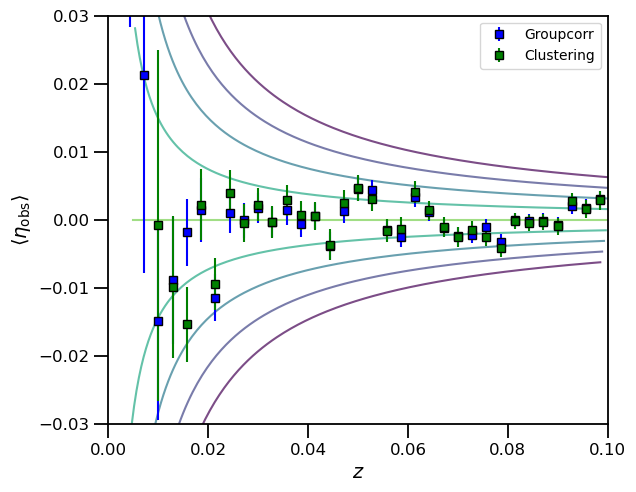

In [11]:
nzbin = 36         # number of redshift bins for plotting
bins = np.linspace(0.0, 0.1, nzbin)
midvals = (bins[0:-1]+bins[1:])/2.0
velarray = np.array([-400.0, -300.0, -200.0, -100.0, 0.0, 100.0, 200.0, 300.0, 400.0])
zcosarray = np.linspace(0.005, 0.1, 200)
zobsarray = np.outer(1.0 + velarray/LightSpeed, (1.0 + zcosarray)) - 1.0
dharray = cosmo.comoving_distance(zcosarray)
dzarray = cosmo.comoving_distance(zobsarray)
logdistarray = np.log10(dzarray/dharray)
cols = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord  = np.array([np.searchsorted(zobsarray[i, :], xcoord[i] / LightSpeed) for i in range(len(velarray))])
ycoord = np.array([logdistarray[i, coord[i]] for i in range(len(velarray))])

data_groupcorr = pd.read_csv(f"/global/cfs/cdirs/desi/science/td/pv/fpgalaxies/Y3/v{version}/FP_pv_cat_v{version}_groupcorr.csv")
data_clustering = Table.read(f"/global/cfs/cdirs/desi/science/td/pv/fpgalaxies/Y3/v{version}/FP_clustering_data_v{version}.fits").to_pandas()
data_groupcorr = data_groupcorr[data_groupcorr["FPcalibrator"]]

zp_groupcorr = weighted_avg_and_std(data_groupcorr["logdist_groupcorr_BGS"].to_numpy(), 1.0/data_groupcorr["logdist_gauss_err_BGS"].to_numpy()**2)
zp_clustering = weighted_avg_and_std(data_clustering["LOGDIST"].to_numpy(), 1.0/data_clustering["LOGDIST_ERR"].to_numpy()**2)

# Now plot the observed logdistance ratios for the original, group corrected and clustering catalogues
ngals_groupcorr, ngals_clustering = np.zeros(nzbin-1), np.zeros(nzbin-1)
logdistmean_groupcorr, logdistmean_err_groupcorr, logdiststd_groupcorr = np.zeros(nzbin-1), np.zeros(nzbin-1), np.zeros(nzbin-1)
logdistmean_clustering, logdistmean_err_clustering, logdiststd_clustering = np.zeros(nzbin-1), np.zeros(nzbin-1), np.zeros(nzbin-1)
for k in range(len(bins)-1):
    index = np.where(np.logical_and(np.logical_and(data_groupcorr["zcmb"] > bins[k], data_groupcorr["zcmb"] <= bins[k+1]), data_groupcorr["FPcalibrator"]==1))[0]
    ngals_groupcorr[k] = len(index)
    if len(index) > 2:
        logdistmean_groupcorr[k], logdistmean_err_groupcorr[k], logdiststd_groupcorr[k] = weighted_avg_and_std(data_groupcorr["logdist_groupcorr_BGS"].to_numpy()[index]-zp_groupcorr[0], 1.0/data_groupcorr["logdist_gauss_err_BGS"].to_numpy()[index]**2)
    index = np.where(np.logical_and(data_clustering["ZCMB"] > bins[k], data_clustering["ZCMB"] <= bins[k+1]))[0]
    ngals_clustering[k] = len(index)
    if len(index) > 2:
        logdistmean_clustering[k], logdistmean_err_clustering[k], logdiststd_clustering[k] = weighted_avg_and_std(data_clustering["LOGDIST"].to_numpy()[index]-zp_clustering[0], 1.0/data_clustering["LOGDIST_ERR"].to_numpy()[index]**2)
        
index_groupcorr = np.where(ngals_groupcorr >= 2)[0]
index_clustering = np.where(ngals_clustering >= 2)[0]

fig = plt.figure()
ax1=fig.add_axes([0.19,0.13,0.78,0.85])
ax1.errorbar(((bins[0:-1]+bins[1:])/2.0)[index_groupcorr], logdistmean_groupcorr[index_groupcorr], yerr=logdistmean_err_groupcorr[index_groupcorr], color='b', markerfacecolor='b', markeredgecolor='k', marker='s', linestyle='None', zorder=1, label="Groupcorr")
ax1.errorbar(((bins[0:-1]+bins[1:])/2.0)[index_clustering], logdistmean_clustering[index_clustering], yerr=logdistmean_err_clustering[index_clustering], color='g', markerfacecolor='g', markeredgecolor='k', marker='s', linestyle='None', zorder=1, label="Clustering")
for i in range(len(velarray)):
    ax1.plot(zobsarray[i], logdistarray[i], color=plt.cm.viridis_r(cols[i]), linestyle='-', alpha=0.7, zorder=0)
ax1.set_xlabel(r'$z$',fontsize=14)
ax1.set_ylabel(r'$\langle\eta_{\mathrm{obs}}\rangle$',fontsize=14)
ax1.set_xlim(0.0, 0.1)
ax1.set_ylim(-0.030, 0.030)
ax1.tick_params(width=1.3)
ax1.tick_params('both',length=10, which='major')
ax1.tick_params('both',length=5, which='minor')
for axis in ['top','left','bottom','right']:
    ax1.spines[axis].set_linewidth(1.3)
for tick in ax1.xaxis.get_ticklabels():
    tick.set_fontsize(12)
for tick in ax1.yaxis.get_ticklabels():
    tick.set_fontsize(12)
plt.legend()
plt.show()